# 04 — Feature Engineering: Rolling Features

Goal: add trajectory-aware features instead of using raw sensor values only.

Rolling mean and rolling standard deviation let the model see recent sensor behavior inside each engine trajectory.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import DEFAULT_RUL_CAP, RANDOM_STATE, SELECTED_SENSORS
from src.data.loading import load_train
from src.features.build_features import (
    add_rul_target,
    add_rolling_features,
    make_feature_list,
    train_val_split_by_unit,
    prepare_xy,
)
from src.models.train_baselines import fit_models, predict_models, evaluate_model_predictions
from src.visualization.plots import plot_actual_vs_predicted


In [3]:
df = load_train(DATA_DIR, "FD001")
df = add_rul_target(df, cap=DEFAULT_RUL_CAP)

selected_sensors = SELECTED_SENSORS
window_size = 5

df_features = add_rolling_features(df, selected_sensors, window_size=window_size)
feature_cols = make_feature_list(selected_sensors, rolling_window=window_size)

print("Feature columns:")
print(feature_cols)
df_features[["unit", "cycle", "RUL"] + feature_cols].head()


Feature columns:
['s_7', 's_12', 's_14', 's_20', 's_21', 's_7_roll_mean_5', 's_12_roll_mean_5', 's_14_roll_mean_5', 's_20_roll_mean_5', 's_21_roll_mean_5', 's_7_roll_std_5', 's_12_roll_std_5', 's_14_roll_std_5', 's_20_roll_std_5', 's_21_roll_std_5']


,unit,cycle,RUL,s_7,s_12,s_14,s_20,s_21,s_7_roll_mean_5,s_12_roll_mean_5,s_14_roll_mean_5,s_20_roll_mean_5,s_21_roll_mean_5,s_7_roll_std_5,s_12_roll_std_5,s_14_roll_std_5,s_20_roll_std_5,s_21_roll_std_5
0,1,1,140,554.36,521.66,8138.62,39.06,23.4190,554.360000,521.660,8138.620000,39.060000,23.419000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2,140,553.75,522.28,8131.49,39.00,23.4236,554.055000,521.970,8135.055000,39.030000,23.421300,0.431335,0.438406,5.041671,0.042426,0.003253
2,1,3,140,554.26,522.42,8133.23,38.95,23.3442,554.123333,522.120,8134.446667,39.003333,23.395600,0.327159,0.404475,3.717450,0.055076,0.044573
3,1,4,140,554.45,522.86,8133.83,38.88,23.3739,554.205000,522.305,8134.292500,38.972500,23.390175,0.313103,0.495950,3.050906,0.076322,0.037977
4,1,5,140,554.00,522.19,8133.80,38.90,23.4044,554.164000,522.282,8134.194000,38.958000,23.393020,0.286234,0.432574,2.651326,0.073621,0.033498


## Train with rolling features

This is still not a deep model. The point is to improve signal quality before moving to uncertainty/policy analysis.


In [4]:
train_df, val_df = train_val_split_by_unit(df_features, random_state=RANDOM_STATE)
X_train, y_train, X_val, y_val = prepare_xy(train_df, val_df, feature_cols)

fitted_models = fit_models(X_train, y_train, random_state=RANDOM_STATE)
predictions = predict_models(fitted_models, X_val)
rolling_metrics = evaluate_model_predictions(y_val, predictions)
rolling_metrics


,Model,MAE,RMSE,R2
0,Gradient Boosting,14.691768,19.802448,0.821017
1,Random Forest,14.940983,20.526835,0.807683
2,Decision Tree,15.950953,21.477449,0.789458
3,Linear Regression,18.564557,23.318600,0.751814


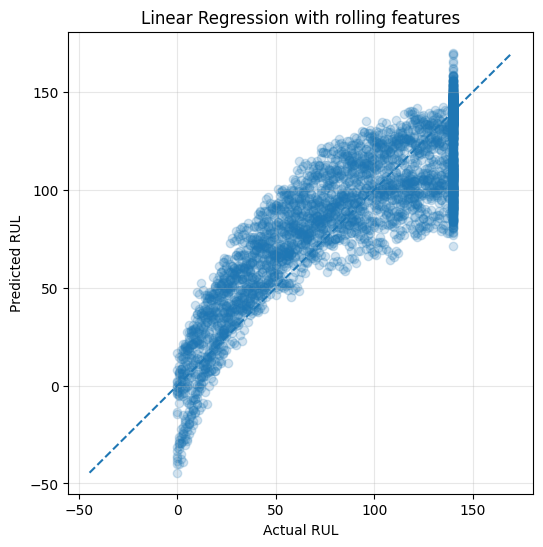

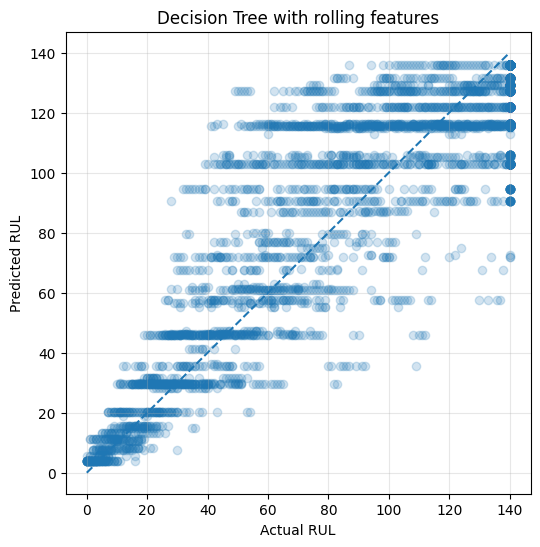

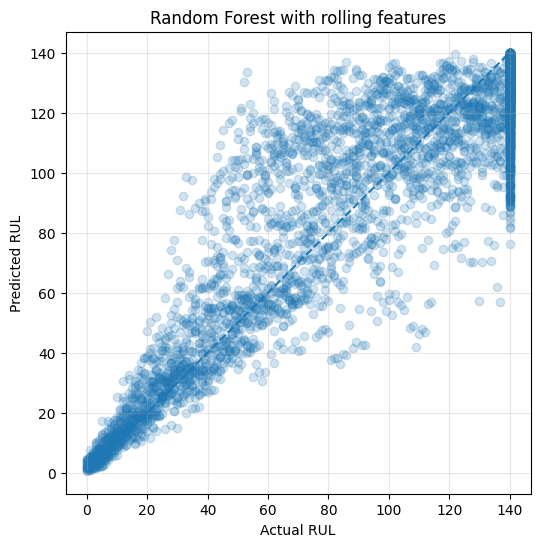

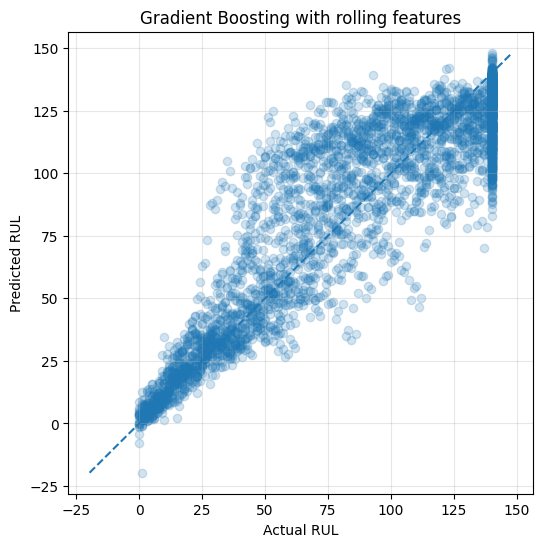

In [5]:
for model_name, y_pred in predictions.items():
    plot_actual_vs_predicted(y_val, y_pred, title=f"{model_name} with rolling features")
    plt.show()


In [6]:
rolling_metrics.to_csv(PROCESSED_DIR / "fd001_rolling_feature_metrics.csv", index=False)
print("Saved rolling-feature metrics")


Saved rolling-feature metrics
